# 03 — Train DAS on Controlled NLI

We trained a vanilla activation-patching baseline in notebook 02. Now we
lift it to **Distributed Alignment Search**: at a *fixed* layer / component /
token position, we learn an orthogonal rotation so that the rotated
low-rank subspace causally implements the high-level variable
`lexical_relation`.

Pipeline:

1. Build train + held-out counterfactual datasets targeting
   `lexical_relation`.
2. Pick one promising `(layer, component, position)` site (here we
   hard-code one informed by the heatmap from notebook 02; in a real
   project you'd peak-pick programmatically from the saved CSV).
3. Train a `LowRankRotatedSpaceIntervention` (`intervention_dim = 4`,
   matching the 4-valued lexical-relation variable) on the train set.
4. Evaluate factual accuracy + IIA on the held-out set.
5. Compare to two controls:
    - **Random-source control.** Replace each source with a randomly
      shuffled source from the eval set. IIA should collapse to chance.
    - **Wrong-variable control.** Re-evaluate the *same trained* DAS
      against counterfactual labels computed for a *different* high-level
      variable (`premise_word_identity`). IIA should also drop, because
      the subspace was aligned to `lexical_relation` specifically.

Runs on CPU in a few minutes with `distilgpt2`.

In [ ]:
# Colab bootstrap: clone this project repo, enter it, and install requirements.
# Run this first in a fresh Colab runtime.
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/aquantumreality/cs221m-das-mqnli.git"
REPO_NAME = "cs221m-das-mqnli"

# Keep Transformers on the PyTorch path and avoid TensorFlow/Keras import issues.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB:
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(repo_root)])
    os.chdir(repo_root)
else:
    # Local/Jupyter fallback: find the existing repository root instead of cloning.
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            repo_root = candidate
            os.chdir(repo_root)
            break
    else:
        raise FileNotFoundError("Could not find repo root with requirements.txt and src/.")

requirements_path = Path("requirements-colab.txt") if Path("requirements-colab.txt").exists() else Path("requirements.txt")
print("Working directory:", Path.cwd())
print("Installing:", requirements_path)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_path)])

# Fallback for environments where pyvene is missing after requirements install.
try:
    import pyvene  # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/stanfordnlp/pyvene.git"])

print("Bootstrap complete. If packages were newly installed, restart the runtime once, then rerun this cell and continue.")

## 1. Setup

In [27]:
import os, sys, pathlib

# Lightweight setup only. No torch / transformers / pyvene imports here.
# This cell should finish almost immediately.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# DAS rotated interventions use torch.linalg.householder_product, which is
# not implemented on Apple MPS. We explicitly avoid MPS below; this env var
# is only an extra safety net if some dependency tries an MPS fallback path.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

_HERE = pathlib.Path.cwd()
for _p in [_HERE, *_HERE.parents]:
    if (_p / 'src').is_dir():
        PROJECT_ROOT = _p
        break
else:
    raise RuntimeError('Could not locate the project root (no src/ found).')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT =', PROJECT_ROOT)

# Colab/GPU defaults. Keep MODEL_NAME identical to notebook 02 so the chosen
# activation-patching site transfers cleanly to DAS.
MODEL_NAME = 'gpt2'

# Fallback site only. Section 3.5 will override these from
# outputs/patching_sweep.csv after you run notebook 02.
LAYER            = 8
COMPONENT        = 'block_output'
INTERVENTION_DIM = 4   # matches the 4 lexical relations
TARGET_VAR       = 'lexical_relation'
USE_SINGLE_TEMPLATE = True    # keeps token positions stable for fixed-position DAS

# Data sizing. Bumped to take advantage of the expanded LEXICAL_PAIRS pool
# (~80 pairs x 2 templates ~= 160 raw examples before counterfactual pairing).
N_TRAIN   = 1024
N_EVAL    = 256
BATCH_SZ  = 8
NUM_EPOCHS = 20
LR         = 1e-3

OUT_DIR = PROJECT_ROOT / 'outputs'
(OUT_DIR / 'das').mkdir(parents=True, exist_ok=True)
print('OUT_DIR =', OUT_DIR)
print('site =', (LAYER, COMPONENT, f'dim={INTERVENTION_DIM}'))

PROJECT_ROOT = /Users/abhiram3001/Downloads/course project stuff
OUT_DIR = /Users/abhiram3001/Downloads/course project stuff/outputs
site = (4, 'block_output', 'dim=4')


## 2. Load model + verbalizer

In [28]:
# First heavy imports happen here: torch + HuggingFace transformers.
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed
from src.utils.seed import get_device
from src.models import load_causal_lm
from src.metrics import LabelVerbalizer

set_seed(0)
# Important: DAS rotated interventions are not MPS-compatible on current
# PyTorch because torch.linalg.householder_product is missing there.
# Use CUDA if available, otherwise CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

tokenizer, model = load_causal_lm(MODEL_NAME, device=DEVICE)
n_layers = getattr(model.config, 'n_layer', getattr(model.config, 'num_hidden_layers', None))
print(f'Loaded {MODEL_NAME} on {DEVICE} (n_layers={n_layers}, hidden={model.config.n_embd})')

verbalizer = LabelVerbalizer.from_tokenizer(
    tokenizer,
    {'entailment': ' yes', 'neutral': ' maybe', 'contradiction': ' no'},
)
verbalizer.token_ids

DEVICE = cpu
Loaded distilgpt2 on cpu (n_layers=6, hidden=768)


{'entailment': 3763, 'neutral': 3863, 'contradiction': 645}

## 3. Build counterfactual datasets

Both targeting the same high-level variable `lexical_relation`, but with
different RNG seeds so the train/eval splits don't share examples.
We require `cf_label != base_label` so chance-level IIA is meaningfully
below 1.

In [29]:
from src.data import build_counterfactual_dataset
from src.data.nli_templates import DEFAULT_TEMPLATES
from src.metrics.logits import decode_label

TEMPLATES = [DEFAULT_TEMPLATES[0]] if USE_SINGLE_TEMPLATE else DEFAULT_TEMPLATES
print('Using templates:', [t.name for t in TEMPLATES])

train_ds = build_counterfactual_dataset(
    tokenizer, target_variable=TARGET_VAR,
    templates=TEMPLATES,
    n_examples=N_TRAIN, seed=0, require_label_change=True,
)
eval_ds = build_counterfactual_dataset(
    tokenizer, target_variable=TARGET_VAR,
    templates=TEMPLATES,
    n_examples=N_EVAL, seed=42, require_label_change=True,
)
print(f'train: {len(train_ds)}   eval: {len(eval_ds)}')

# DAS is a fixed-position intervention. Use the most common hypothesis-word
# position in the training set unless you manually choose a position from the
# patching heatmap.
from collections import Counter
pos_counts = Counter(int(ex.intervention_pos) for ex in train_ds.examples)
FIXED_POSITION = pos_counts.most_common(1)[0][0]
print('train intervention-position counts:', dict(pos_counts))
print('Using FIXED_POSITION =', FIXED_POSITION)

# Sanity peek: how does the *unintervened* base model do on these prompts?
with torch.no_grad():
    out = model(
        input_ids=eval_ds._base_input_ids.to(DEVICE),
        attention_mask=eval_ds._base_attn.to(DEVICE),
    )
    preds = decode_label(out.logits, verbalizer, attention_mask=eval_ds._base_attn.to(DEVICE)).cpu()
gold = torch.tensor([ex.base_label_id for ex in eval_ds.examples])
print(f'unintervened base accuracy on eval set: {(preds == gold).float().mean().item():.2f}')

train: 512   eval: 128
train intervention-position counts: {9: 272, 10: 8, 8: 216, 1: 16}
Using FIXED_POSITION = 9
unintervened base accuracy on eval set: 0.34


## 3.5. Choose DAS Site From Patching Sweep

Run notebook `02_activation_patching_nli.ipynb` first with the same `MODEL_NAME` and template setting. It writes `outputs/patching_sweep.csv`, a long-form table with one row per `(example, layer, component, position)` intervention.

Why this matters:

- **Rerun patching** is the localization step. It asks: "Where does a simple source→base activation patch most change the answer toward the high-level counterfactual label?"
- **Choose the best patching site** gives DAS a plausible starting site. DAS is expensive and fixed-site, so we do not want to train rotations at arbitrary layers/positions.
- **Rerun DAS at that site** tests whether a *learned rotated subspace* at the same location can causally implement `lexical_relation`, not just whether raw patching has some effect.
- **Compare to controls** checks whether the result is meaningful. A good DAS result should beat random-source and wrong-variable controls.

This cell ranks sites by average IIA first and logit-recovery second, then sets:

- `LAYER`
- `COMPONENT`
- `FIXED_POSITION`

If the CSV is missing, the notebook keeps the fallback site from the setup cell.

In [ ]:
PATCHING_CSV = OUT_DIR / 'patching_sweep.csv'
USE_PATCHING_SITE = True

if USE_PATCHING_SITE and PATCHING_CSV.exists():
    patch_df = pd.read_csv(PATCHING_CSV)

    # Aggregate over examples. Higher IIA is primary; recovery is tie-breaker.
    site_scores = (
        patch_df.groupby(['component', 'layer', 'position'])
        .agg(
            iia=('iia_correct', 'mean'),
            recovery=('recovery', 'mean'),
            n=('example_id', 'nunique'),
        )
        .reset_index()
        .sort_values(['iia', 'recovery'], ascending=False)
    )

    display(site_scores.head(20))

    best = site_scores.iloc[0]
    COMPONENT = str(best['component'])
    LAYER = int(best['layer'])
    FIXED_POSITION = int(best['position'])

    print('Selected DAS site from patching sweep:')
    print({
        'component': COMPONENT,
        'layer': LAYER,
        'fixed_position': FIXED_POSITION,
        'patching_iia': float(best['iia']),
        'patching_recovery': float(best['recovery']),
    })
else:
    print(f'No patching CSV found at {PATCHING_CSV}.')
    print('Using fallback site from setup/dataset cells:')
    print({'component': COMPONENT, 'layer': LAYER, 'fixed_position': FIXED_POSITION})

## 4. Configure DAS and train

`make_das_config` builds an `IntervenableConfig` whose intervention is a
`LowRankRotatedSpaceIntervention` of dimension `INTERVENTION_DIM` at the
chosen `(layer, component)`. `train_das_alignment` freezes the base LM
and trains only the rotation matrix.

In [30]:
# First pyvene-heavy imports happen here.
# Reload the DAS modules so notebook kernels pick up edits made during debugging.
import importlib
import src.interventions.das_config as das_config_module
import src.interventions.train_das as train_das_module

importlib.reload(das_config_module)
importlib.reload(train_das_module)

make_das_config = das_config_module.make_das_config
train_das_alignment = train_das_module.train_das_alignment

das_config = make_das_config(
    model,
    layer=LAYER,
    component=COMPONENT,
    intervention_dim=INTERVENTION_DIM,
    unit='pos',
)
print(das_config.__dict__['_das_meta'])

log_path = OUT_DIR / 'das' / f'train_history_{TARGET_VAR}_L{LAYER}_{COMPONENT}.json'
out = train_das_alignment(
    model, tokenizer, train_ds, das_config,
    num_epochs=NUM_EPOCHS, lr=LR, batch_size=BATCH_SZ,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=FIXED_POSITION,
    log_path=str(log_path), progress=True,
)
intervenable_lex = out.intervenable
history = out.history
print('saved history to', log_path)
print('final train IIA:', history[-1]['train_iia'])

{'layer': 4, 'component': 'block_output', 'intervention_dim': 4, 'unit': 'pos', 'max_number_of_units': 1, 'hidden_size': 768, 'intervention_class': 'LowRankRotatedSpaceIntervention', 'low_rank_supported': True}


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 0:   0%|          | 0/64 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/64 [00:00<?, ?it/s]

epoch 2:   0%|          | 0/64 [00:00<?, ?it/s]

...

epoch 16:   0%|          | 0/64 [00:00<?, ?it/s]

epoch 17:   0%|          | 0/64 [00:00<?, ?it/s]

epoch 18:   0%|          | 0/64 [00:00<?, ?it/s]

epoch 19:   0%|          | 0/64 [00:00<?, ?it/s]

saved history to /Users/abhiram3001/Downloads/course project stuff/outputs/das/train_history_lexical_relation_L4_block_output.json
final train IIA: 0.435546875


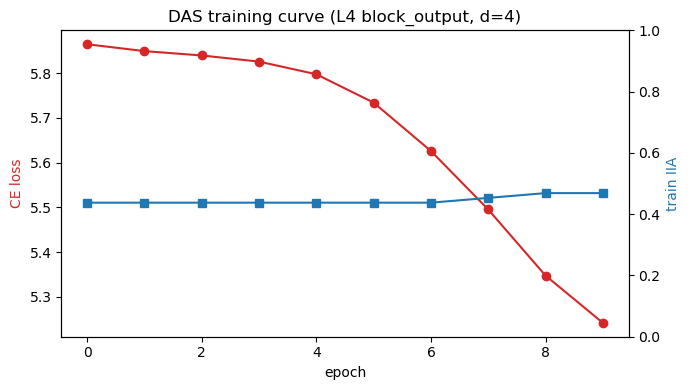

In [21]:
# Plot training curve.
hist_df = pd.DataFrame(history)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(hist_df['epoch'], hist_df['loss'], marker='o', label='train loss', color='tab:red')
ax1.set_xlabel('epoch'); ax1.set_ylabel('CE loss', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(hist_df['epoch'], hist_df['train_iia'], marker='s', label='train IIA', color='tab:blue')
ax2.set_ylabel('train IIA', color='tab:blue'); ax2.set_ylim(0, 1.0)
ax1.set_title(f'DAS training curve (L{LAYER} {COMPONENT}, d={INTERVENTION_DIM})')
fig.tight_layout()
fig.savefig(OUT_DIR / 'das' / 'training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluate on held-out CF pairs (correct alignment)

In [31]:
import importlib
import src.interventions.eval_iia as eval_iia_module

importlib.reload(eval_iia_module)
evaluate_das_iia = eval_iia_module.evaluate_das_iia

res_lex = evaluate_das_iia(
    intervenable_lex, eval_ds, tokenizer,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=FIXED_POSITION,
)
print(f"factual_accuracy = {res_lex['factual_accuracy']:.3f}")
print(f"IIA              = {res_lex['iia']:.3f}   (n={res_lex['n_examples']})")
print('IIA per class    :', {k: round(v, 3) for k, v in res_lex['iia_per_class'].items()})
res_lex['confusion']

factual_accuracy = 0.336
IIA              = 0.469   (n=128)
IIA per class    : {'entailment': 1.0, 'neutral': 0.082, 'contradiction': 0.0}


,pred_entailment,pred_neutral,pred_contradiction
true_entailment,56,0,0
true_neutral,45,4,0
true_contradiction,23,0,0


## 6. Random-source control

We **shuffle** the source rows of the eval dataset so each base is paired
with a random other source. The high-level counterfactual labels are
unchanged, so if the patched activation no longer actually carries the
correct value of `lexical_relation`, IIA should fall to chance.

In [32]:
import copy

def shuffle_sources(dataset, seed=0):
    """Return a shallow-copied dataset whose source rows are permuted.
    cf labels and intervention positions stay tied to the *base*."""
    rng = np.random.RandomState(seed)
    n = len(dataset)
    perm = rng.permutation(n)
    # Re-rolling all-same-position pathological perms is overkill for
    # n>=4; just make sure no example is mapped to itself.
    for _ in range(10):
        if not np.any(perm == np.arange(n)): break
        perm = rng.permutation(n)
    new_ds = copy.copy(dataset)
    new_ds._source_input_ids = dataset._source_input_ids[perm].clone()
    new_ds._source_attn      = dataset._source_attn[perm].clone()
    new_ds.examples = list(dataset.examples)  # cf labels untouched
    return new_ds

eval_random = shuffle_sources(eval_ds, seed=1)
res_random = evaluate_das_iia(
    intervenable_lex, eval_random, tokenizer,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=FIXED_POSITION,
)
print(f"random-source IIA = {res_random['iia']:.3f}   (n={res_random['n_examples']})")
res_random['confusion']

random-source IIA = 0.453   (n=128)


,pred_entailment,pred_neutral,pred_contradiction
true_entailment,56,0,0
true_neutral,47,2,0
true_contradiction,23,0,0


## 7. Wrong-variable control

We build a second eval set whose counterfactual labels are computed for
the **wrong** intermediate variable (`premise_word_identity`) at the
**same intervention site** (hypothesis-word position) as the trained
DAS. The trained rotation should not generalise: IIA should drop.

In [33]:
eval_wrong = build_counterfactual_dataset(
    tokenizer,
    target_variable='premise_word_identity',
    intervention_word='hypothesis_word',   # keep patch site fixed
    n_examples=N_EVAL, seed=42, require_label_change=True,
)
print(f'wrong-variable eval set: {len(eval_wrong)}')
res_wrong = evaluate_das_iia(
    intervenable_lex, eval_wrong, tokenizer,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=FIXED_POSITION,
)
print(f"wrong-variable IIA = {res_wrong['iia']:.3f}")
res_wrong['confusion']

wrong-variable eval set: 128
wrong-variable IIA = 0.094


,pred_entailment,pred_neutral,pred_contradiction
true_entailment,10,0,0
true_neutral,8,2,0
true_contradiction,107,1,0


## 8. Summary

In [34]:
summary = pd.DataFrame([
    {'condition': 'lexical_relation (trained variable)',
     'factual_acc': res_lex['factual_accuracy'],
     'IIA':         res_lex['iia'],
     'n':           res_lex['n_examples']},
    {'condition': 'random-source control',
     'factual_acc': res_random['factual_accuracy'],
     'IIA':         res_random['iia'],
     'n':           res_random['n_examples']},
    {'condition': 'wrong-variable control (premise_word_identity)',
     'factual_acc': res_wrong['factual_accuracy'],
     'IIA':         res_wrong['iia'],
     'n':           res_wrong['n_examples']},
])
summary['IIA'] = summary['IIA'].round(3)
summary['factual_acc'] = summary['factual_acc'].round(3)
summary.to_csv(OUT_DIR / 'das' / 'iia_summary.csv', index=False)
summary

,condition,factual_acc,IIA,n
0,lexical_relation (trained variable),0.336,0.469,128
1,random-source control,0.336,0.453,128
2,wrong-variable control (premise_word_identity),0.484,0.094,128


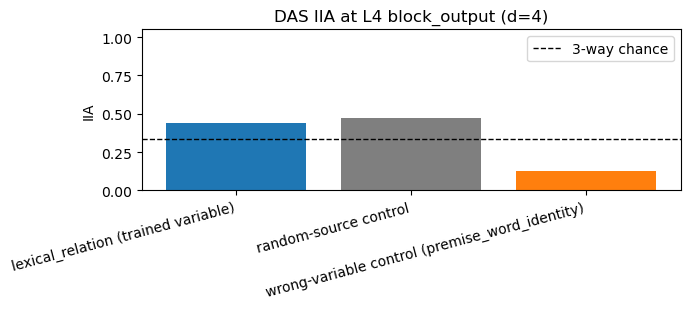

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(summary['condition'], summary['IIA'], color=['tab:blue', 'tab:gray', 'tab:orange'])
ax.axhline(1/3, color='black', linestyle='--', linewidth=1, label='3-way chance')
ax.set_ylim(0, 1.05); ax.set_ylabel('IIA')
ax.set_title(f'DAS IIA at L{LAYER} {COMPONENT} (d={INTERVENTION_DIM})')
for tick in ax.get_xticklabels():
    tick.set_rotation(15); tick.set_ha('right')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUT_DIR / 'das' / 'iia_bars.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation cheat sheet

- **`lexical_relation` IIA**  — ceiling we can reach with this site /
  subspace dimension. If this is near chance, the alignment is failing;
  try a different layer, a different component, or a larger
  `INTERVENTION_DIM`.
- **random-source IIA**  — lower bound. Should be at or near 3-way
  chance (~0.33). If it's high, your dataset is leaking the answer
  somewhere outside the patched site.
- **wrong-variable IIA**  — specificity check. Should also be near
  chance. If it's close to the `lexical_relation` IIA, the trained
  subspace is encoding something more general (e.g. "the hypothesis
  word identity") and isn't specifically aligned to `lexical_relation`.

### Next steps

- Sweep `(LAYER, COMPONENT, INTERVENTION_DIM)` and pick the site that
  maximises the IIA *gap* between the trained and the wrong-variable
  conditions.
- Swap the LowRankRotatedSpaceIntervention for the boundary-learning
  Boundless DAS variant (see `Boundless_DAS.ipynb`).
- Move from `distilgpt2` to `gpt2` / `gpt2-medium` and see how the
  picture changes.